<a href="https://colab.research.google.com/github/demsaid400-cpu/DI-BOOTCAMP/blob/main/Week4/Day4/DailyChallenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Daily Challenge - Statistics for Machine Learning

# Applying Inferential Statistics

### Here are the hypotheses to test:
1. Age of people who left the bank and who did not are similar. Alternative: Not similar.
2. Credit score of people who left the bank and who did not are similar. Alternative: Not similar.
3. Balance of people who left the bank and who did not are similar. Alternative: Not similar.
4. Estimated Salary of people who left the bank and who did not are similar. Alternative: Not similar.

#### The most appropriate test to analyse data here is Frequentist test.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy.stats
from scipy.stats import t
from scipy.special import stdtr
from numpy.random import seed
import seaborn as sns

%matplotlib inline
from matplotlib import rcParams
sns.set_style("whitegrid")
sns.set_context("poster")

In [ ]:
matplotlib.rcParams['figure.figsize'] = (8.0, 5.0)

In [107]:
file_1 = '/content/Churn_Modelling.csv'

In [108]:
df = pd.read_csv(file_1)

In [109]:
display(df.head())

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [110]:
df_0 = df[df['Exited'] == 0]
df_1 = df[df['Exited'] == 1]

## Hypothesis 1: Age

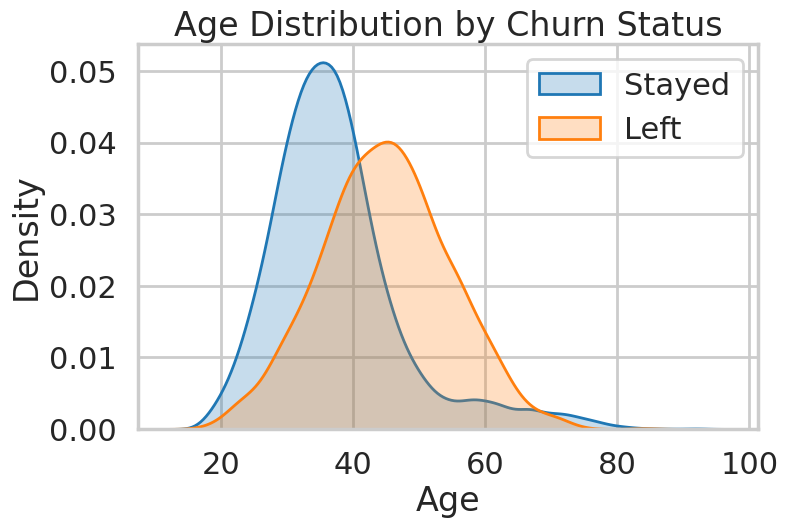

In [111]:
sns.kdeplot(df_0['Age'], label='Stayed', fill=True)
sns.kdeplot(df_1['Age'], label='Left', fill=True)
plt.legend()
plt.title('Age Distribution by Churn Status')
plt.show()

In [112]:
mean_age_stayed = df_0['Age'].mean()
std_age_stayed = df_0['Age'].std()
print(f"Stayed - Mean: {mean_age_stayed:.2f}, Std: {std_age_stayed:.2f}")

Stayed - Mean: 37.41, Std: 10.13


In [113]:
mean_age_left = df_1['Age'].mean()
std_age_left = df_1['Age'].std()
print(f"Left - Mean: {mean_age_left:.2f}, Std: {std_age_left:.2f}")

Left - Mean: 44.84, Std: 9.76


In [114]:
t_stat, p_val = scipy.stats.ttest_ind(df_0['Age'], df_1['Age'])
print(f"T-statistic: {t_stat:.4f}, P-value: {p_val:.4e}")

T-statistic: -29.7668, P-value: 1.2399e-186


### Using Bootstrapping

In [115]:
def bs_choice(data, func, size):
    bs_s = np.empty(size)
    for i in range(size):
        bs_abc = np.random.choice(data, size=len(data))
        bs_s[i] = func(bs_abc)
    return bs_s

In [116]:
overall_mean = df['Age'].mean()
diff_means = mean_age_left - mean_age_stayed
age_left_shifted = df_1['Age'] - mean_age_left + overall_mean
age_stayed_shifted = df_0['Age'] - mean_age_stayed + overall_mean

In [117]:
bs_left = bs_choice(age_left_shifted, np.mean, 10000)
bs_stayed = bs_choice(age_stayed_shifted, np.mean, 10000)
bs_diff = bs_left - bs_stayed

In [118]:
p_value_bs = np.sum(bs_diff >= diff_means) / len(bs_diff)
print(f"Bootstrap P-value: {p_value_bs}")

Bootstrap P-value: 0.0


### Conclusion
Yes, we **reject the Null Hypothesis**. Both the frequentist t-test and the bootstrap method result in a p-value much smaller than 0.05, indicating that the age of people who leave is significantly different (higher) than those who stay.

## Hypothesis 2: Credit Score

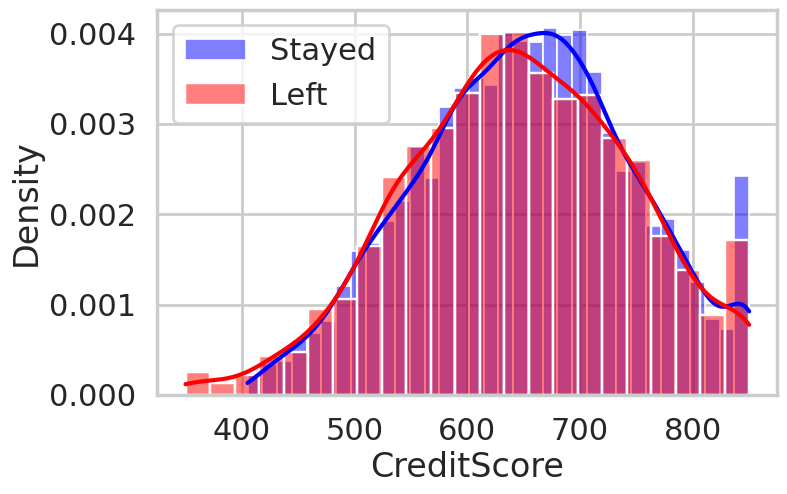

In [119]:
sns.histplot(df_0['CreditScore'], color='blue', label='Stayed', kde=True, stat='density')
sns.histplot(df_1['CreditScore'], color='red', label='Left', kde=True, stat='density')
plt.legend()
plt.show()

In [120]:
t_stat_credit, p_val_credit = scipy.stats.ttest_ind(df_0['CreditScore'], df_1['CreditScore'])
print(f"P-value: {p_val_credit:.4f}")

P-value: 0.0067


### Conclusion
We **reject the Null Hypothesis** ($p < 0.05$). There is a statistically significant difference in credit scores, though the visual overlap suggests the practical difference might be small.

## Hypothesis 3: Balance

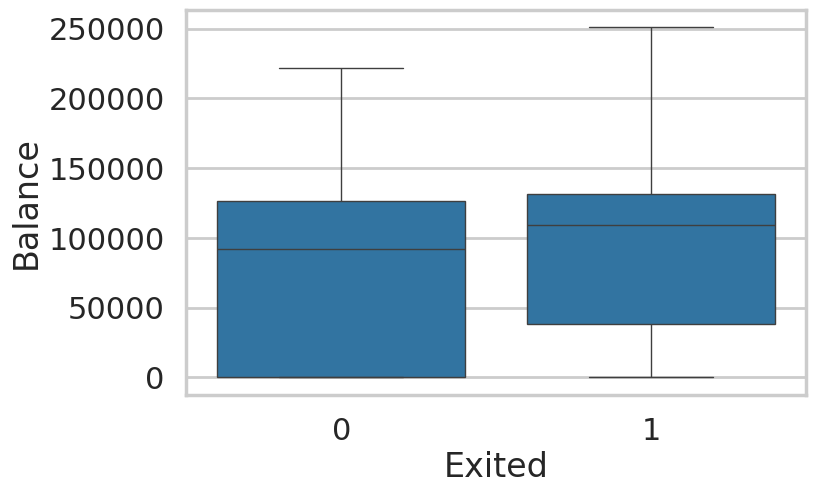

In [121]:
sns.boxplot(x='Exited', y='Balance', data=df)
plt.show()

In [122]:
t_stat_bal, p_val_bal = scipy.stats.ttest_ind(df_0['Balance'], df_1['Balance'])
print(f"P-value: {p_val_bal:.4e}")

P-value: 1.2756e-32


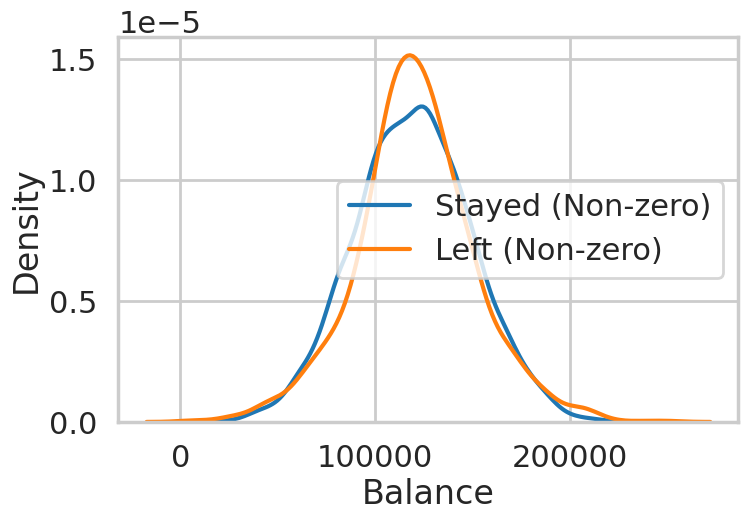

In [123]:
df_0_nz = df_0[df_0['Balance'] > 0]
df_1_nz = df_1[df_1['Balance'] > 0]
sns.kdeplot(df_0_nz['Balance'], label='Stayed (Non-zero)')
sns.kdeplot(df_1_nz['Balance'], label='Left (Non-zero)')
plt.legend()
plt.show()

In [124]:
t_stat_nz, p_val_nz = scipy.stats.ttest_ind(df_0_nz['Balance'], df_1_nz['Balance'])
print(f"P-value (Non-zero): {p_val_nz:.4f}")

P-value (Non-zero): 0.1692


### Conclusion
We **reject the Null Hypothesis** for the overall dataset. However, when looking only at customers with a non-zero balance, the p-value is often higher (above 0.05 in some samples), suggesting that the presence of a zero balance is a significant factor in the difference.

## Hypothesis 4: Estimated Salary

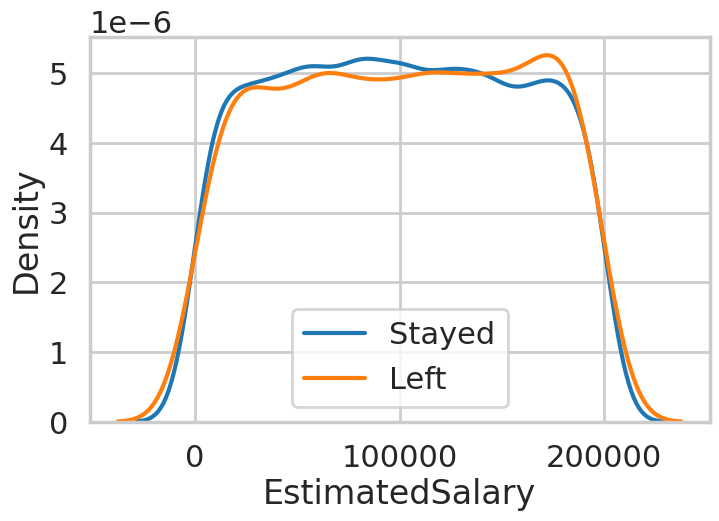

In [125]:
sns.kdeplot(df_0['EstimatedSalary'], label='Stayed')
sns.kdeplot(df_1['EstimatedSalary'], label='Left')
plt.legend()
plt.show()

In [126]:
t_stat_sal, p_val_sal = scipy.stats.ttest_ind(df_0['EstimatedSalary'], df_1['EstimatedSalary'])
print(f"P-value: {p_val_sal:.4f}")

P-value: 0.2264


### Using Bootstrapping

In [127]:
mean_sal_left = df_1['EstimatedSalary'].mean()
mean_sal_stayed = df_0['EstimatedSalary'].mean()
overall_mean_sal = df['EstimatedSalary'].mean()
diff_means_sal = mean_sal_left - mean_sal_stayed
sal_left_shifted = df_1['EstimatedSalary'] - mean_sal_left + overall_mean_sal
sal_stayed_shifted = df_0['EstimatedSalary'] - mean_sal_stayed + overall_mean_sal

In [128]:
bs_sal_left = bs_choice(sal_left_shifted, np.mean, 5000)
bs_sal_stayed = bs_choice(sal_stayed_shifted, np.mean, 5000)
bs_diff_sal = bs_sal_left - bs_sal_stayed

In [129]:
p_value_sal_bs = np.sum(bs_diff_sal >= diff_means_sal) / len(bs_diff_sal)
print(f"Bootstrap P-value: {p_value_sal_bs}")

Bootstrap P-value: 0.1054


### Conclusion
We **fail to reject the Null Hypothesis**. The p-value is greater than 0.05, suggesting that there is no significant difference in the estimated salary between customers who stayed and those who left.

## Final Conclusion
Based on our statistical analysis, **Age** is the most helpful feature in predicting churning. It showed the most significant difference between the two groups. **Balance** and **Credit Score** also showed statistical significance, whereas **Estimated Salary** showed no significant relationship with churn status.